## Protegrity Anonymization SDK
Anonymization is a privacy-enhancing technology that uses proven mathematical techniques called privacy models to protect your data.

This Notebook provides an overview of Protegrity Anonymization.

It performs the following tasks:
- Detects quasi-identifiers in a patient dataset.
- Anonymizes the dataset with k-anonymity privacy guarantees.
- Calculates re-identification risk before and after anonymization.
- Measures information loss to evaluate data utility.

### Key Features

The following are the key features of the Protegrity Anonymization SDK.

- **Privacy Models**: k-anonymity, l-diversity, t-closeness.
- **Auto-Detection**: Automatic QI/DI/SA column detection.
- **Solution Reuse**: `apply_anon()` re-applies a saved solution to new data batches without recomputing.
- **Risk Metrics**: Calculate re-identification risk (prosecutor, journalist, marketer).
- **Quality Metrics**: Measure information loss from anonymization.

For more information about REST APIs, refer to the <a href="http://localhost:8085/pty/anonymization/v3/docs"> Swagger Doc </a>

Unlike tokenization,where one can obtain the actual data given the credentials, Anonymization is a irreversible data transformation, due to which Anonymized data will have information loss to protect Privacy.Protegrity Anonymization optimizes fundamental privacy-utility trade-off to ensure maximum data quality within the privacy goals. This trade-off can be further optimized via the importance parameter.
The following figure illustrates the above concepts.
![Image showing Anonymization and privacy-utility tradeoff](tradeoff.png)


### Step 1: Install & Import dependencies.


In [ ]:
%pip install pandas matplotlib seaborn protegrity-anonymization-sdk

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anonymization_sdk import AnonymizationClient

SERVICE_EP = "http://localhost:8085/pty/anonymization/v3"

### Step 2: Load and explore the data

Load a patient dataset and understand its structure and basic statistics.

In [17]:
# Work with 10 k rows for speed.
# The SDK accepts a list-of-dicts (records) as well as file paths, so we can
# pass df_small.to_dict(orient="records") directly — no temp file needed.
df_small = pd.read_csv("datastore/patient_data.csv").head(10_000)
records = df_small.to_dict(orient="records")

display(df_small.head(), df_small.describe())

,patient_id,name,age,gender,zip_code,region,disease,blood_type,diagnosis_date,annual_income,insurance_type,education_level,num_visits
0,P000001,Laura Walker,69,Male,12001,Northeast,Osteoporosis,O+,2020-08-06,35501,Medicare,Less than High School,19
1,P000002,Barbara Reyes,32,Male,11001,Northeast,Diabetes Type 2,A+,2021-08-09,51007,Medicaid,High School,29
2,P000003,Diane Bennett,89,Female,60002,Midwest,Osteoporosis,A+,2020-03-26,36466,Other,High School,26
3,P000004,Rachel Richardson,78,Male,33001,Southeast,Osteoporosis,A+,2021-05-26,54006,Medicare,Some College,44
4,P000005,Ryan Price,38,Male,33002,Southeast,Sleep Apnea,A-,2020-01-23,131385,Other,Master's,29


,age,zip_code,annual_income,num_visits
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,53.539700,54078.032600,82173.99610,24.882700
std,20.757324,31616.330621,54156.77381,14.264729
min,18.000000,10001.000000,20009.00000,1.000000
25%,36.000000,30002.000000,40580.00000,12.000000
50%,53.000000,60001.000000,63219.00000,25.000000
75%,72.000000,85002.000000,110674.25000,37.000000
max,89.000000,98002.000000,249944.00000,49.000000


### Step 3: Calculate re-identification risk on original data

Before anonymizing, measure how vulnerable the original dataset is to re-identification attacks using prosecutor, journalist, and marketer risk models.

In [18]:
# ──────────────────────────────────────────────── Risk (Original) ──────────────────────────────────────────────────
client = AnonymizationClient(base_url=SERVICE_EP)

original_risk = client.calculate_risk(
    data=records,
    quasi_identifiers=["age", "gender", "zip_code", "region"],
)

print(f"k-Anonymity level: {original_risk.k_anonymity}")
print(f"Overall risk level: {original_risk.highest_risk_level}")
print(f"Prosecutor risk: {original_risk.prosecutor.overall_risk:.3f} ({original_risk.prosecutor.risk_level})")
print(f"Journalist risk: {original_risk.journalist.overall_risk:.3f} ({original_risk.journalist.risk_level})")
print(f"Marketer risk:   {original_risk.marketer.overall_risk:.3f} ({original_risk.marketer.risk_level})")
print(f"Equivalence classes: {original_risk.num_equivalence_classes}")
print(f"Smallest class size: {original_risk.smallest_class_size}")

k-Anonymity level: 1
Overall risk level: very_high
Prosecutor risk: 1.000 (very_high)
Journalist risk: 1.000 (very_high)
Marketer risk:   0.486 (high)
Equivalence classes: 4862
Smallest class size: 1


### Step 4: Detect quasi-identifiers

The SDK's ML-based detector automatically classifies every column:

| Type | Meaning | What happens |
|------|---------|-------------|
| **Direct identifier** | Uniquely identifies a person (e.g. name, ID) | **Removed** entirely |
| **Quasi-identifier** | Could re-identify when combined (e.g. age + zip) | **Generalized** (e.g. age 69 → "65–70") |
| **Sensitive** | The attribute we want to protect (e.g. disease) | **Kept as-is** — this is what k-anonymity shields |
| **Non-sensitive** | Low re-identification risk | **Kept as-is** |

We hint `disease` as sensitive — the column whose link to a person we want to break.

In [19]:
# ──────────────────────────────────────────────── Detect QIs ──────────────────────────────────────────────────────
# Hint what we already know about the data:
#  - patient_id / name  → direct identifiers (will be removed)
#  - disease            → the sensitive attribute we want to protect
#  - High-cardinality continuous columns (income, dates, visit counts) are poor
#    QI candidates — they create too many equivalence classes, making k-anonymity
#    impossible without extreme suppression.  We skip them.
detection = client.detect_qi(
    data=records,
    known_identifiers=["patient_id", "name"],
    known_sensitive=["disease"],
    ignore_columns=["annual_income", "diagnosis_date", "num_visits"],
    max_quasi_identifiers=5,
)

print(f"Detection method: {detection.detection_method}")
print(f"Direct identifiers: {detection.direct_identifiers}")
print(f"Quasi-identifiers:  {detection.quasi_identifiers}")
print(f"Sensitive attrs:    {detection.sensitive_attributes}")
print(f"Non-sensitive:      {detection.non_sensitive_attributes}")

Detection method: heuristic
Direct identifiers: ['patient_id', 'name']
Quasi-identifiers:  ['age', 'gender', 'zip_code', 'region', 'education_level']
Sensitive attrs:    ['disease']
Non-sensitive:      ['blood_type', 'insurance_type']


### Step 5: Anonymize the data

Build the attribute classification from the detection result and apply **k-anonymity (k = 5)**.
Every person in the output is indistinguishable from at least 4 others on the quasi-identifier columns.

In [ ]:
# ──────────────────────────────────────────────── Anonymize ────────────────────────────────────────────────────────
# Build attribute list directly from the detection result.
# Hierarchy types:
#   "interval"  – numeric columns: groups values into bins  (age 69 → "[65-70)")
#   "masking"   – string columns: replaces chars from the end with mask_char
#                 ⚠ short strings (like blood_type "A+") get fully masked to "***"

def _hierarchy(col):
    """Pick a hierarchy based on column dtype."""
    if df_small[col].dtype in ("int64", "float64"):
        return {"type": "interval",
                "params": {"intervals": [5, 10, 20],
                           "lower_bound": int(df_small[col].min()),
                           "upper_bound": int(df_small[col].max())}}  # bounds computed locally from df_small
    return {"type": "masking", "params": {"max_level": 3, "mask_char": "*"}}

attributes = (
    [{"name": c, "type": "direct_identifier"} for c in detection.direct_identifiers]
  + [{"name": c, "type": "quasi_identifier", "hierarchy": _hierarchy(c)}
     for c in detection.quasi_identifiers]
  + [{"name": c, "type": "sensitive"} for c in detection.sensitive_attributes]
  + [{"name": c, "type": "insensitive"} for c in detection.non_sensitive_attributes]
  + [{"name": c, "type": "insensitive"} for c in df_small.columns
     if c not in {a for d in (detection.direct_identifiers, detection.quasi_identifiers,
                              detection.sensitive_attributes, detection.non_sensitive_attributes)
                  for a in d}]
)

for a in attributes:
    h = f"  hierarchy={a['hierarchy']['type']}" if "hierarchy" in a else ""
    print(f"  {a['name']:20s} → {a['type']}{h}")

result = client.anonymize(
    data=records,
    privacy_model="k-anonymity",
    k=5,
    max_suppression=0.60,
    attributes=attributes,
    use_lattice_search=True,
)

anon_df = pd.DataFrame(result.data)
print(f"\n✓ Anonymized {result.row_count:,} rows  ({len(df_small.columns)} cols → {len(anon_df.columns)} cols)")
print(f"  Suppressed: {result.suppressed_count:,}")
print(f"  Suppression rate: {result.suppressed_count / (result.row_count + result.suppressed_count) * 100:.1f}%")
print(f"  Information loss: {result.metrics.information_loss:.4f}")

In [ ]:
# ──────────────── What changed? ────────────────
qi_cols = detection.quasi_identifiers

print("─── Columns removed (direct identifiers) ───")
print(f"  {set(df_small.columns) - set(anon_df.columns)}\n")

print("─── Row count ───")
print(f"  Original:   {len(df_small):>8,}")
print(f"  Anonymized: {len(anon_df):>8,}  ({len(df_small) - len(anon_df):,} rows suppressed)\n")

print("─── Unique values in quasi-identifier columns (before → after) ───")
for col in qi_cols:
    orig_unique = df_small[col].nunique()
    anon_unique = anon_df[col].nunique() if col in anon_df.columns else 0
    print(f"  {col:15s}  {orig_unique:>5} → {anon_unique:>5}")

print("\n─── Sample of anonymized data ───")
display(anon_df.head(10))

# Show generalized values for QI columns
print("\n─── Example QI values (original → anonymized) ───")
for col in qi_cols:
    if col in anon_df.columns:
        orig_vals = sorted(df_small[col].unique())[:5]
        anon_vals = sorted(anon_df[col].unique())[:5]
        print(f"  {col}:")
        print(f"    Original sample:   {orig_vals}")
        print(f"    Anonymized sample: {anon_vals}")

### Step 6: Calculate re-identification risk on anonymized data

Measure the risk after anonymization to verify privacy improvement.

In [22]:
# ──────────────────────────────────────────────── Risk (Anonymized) ────────────────────────────────────────────────
qi_columns = detection.quasi_identifiers

anon_risk = client.calculate_risk(
    data=anon_df.to_dict(orient="records"),
    quasi_identifiers=qi_columns,
)

print(f"k-Anonymity level: {anon_risk.k_anonymity}")
print(f"Overall risk level: {anon_risk.highest_risk_level}")
print(f"Prosecutor risk: {anon_risk.prosecutor.overall_risk:.3f} ({anon_risk.prosecutor.risk_level})")
print(f"Journalist risk: {anon_risk.journalist.overall_risk:.3f} ({anon_risk.journalist.risk_level})")
print(f"Marketer risk:   {anon_risk.marketer.overall_risk:.3f} ({anon_risk.marketer.risk_level})")
print(f"Equivalence classes: {anon_risk.num_equivalence_classes}")
print(f"Smallest class size: {anon_risk.smallest_class_size}")

k-Anonymity level: 5
Overall risk level: medium
Prosecutor risk: 0.200 (medium)
Journalist risk: 0.200 (medium)
Marketer risk:   0.158 (medium)
Equivalence classes: 767
Smallest class size: 5


### Step 7: Measure information loss

Compare original and anonymized data to quantify information loss from the anonymization process.

In [23]:
# ──────────────────────────────────────────────── Metrics ──────────────────────────────────────────────────────────
metrics = client.measure(
    original_data=records,
    anonymized_data=anon_df.to_dict(orient="records"),
    quasi_identifiers=qi_columns,
)

print(f"Information loss: {metrics.information_loss:.4f}")
print(f"\nDetailed metrics:")
for key, value in metrics.metrics.items():
    print(f"  {key}: {value}")

Information loss: 0.4432

Detailed metrics:
  ambiguity: 0.6778496794871794
  r_squared: 0.16267499795000462
  combined_loss: 0.44322821346160524
  sse_sst_ratio: 0.8373250020499954
  discernibility: 0.5135000277780003
  precision_loss: 0.33782051282051284
  suppression_rate: 0.5135
  mean_squared_error: 0.1492697987546349
  non_uniform_entropy: 0.33782051282051284
  sum_of_squared_errors: 0.8373250020499954
  average_equivalence_class_size: 0.0005198800849883093


### Step 8: Visualize Results
<p>Comparison of risk metrics and data distributions before and after anonymization.

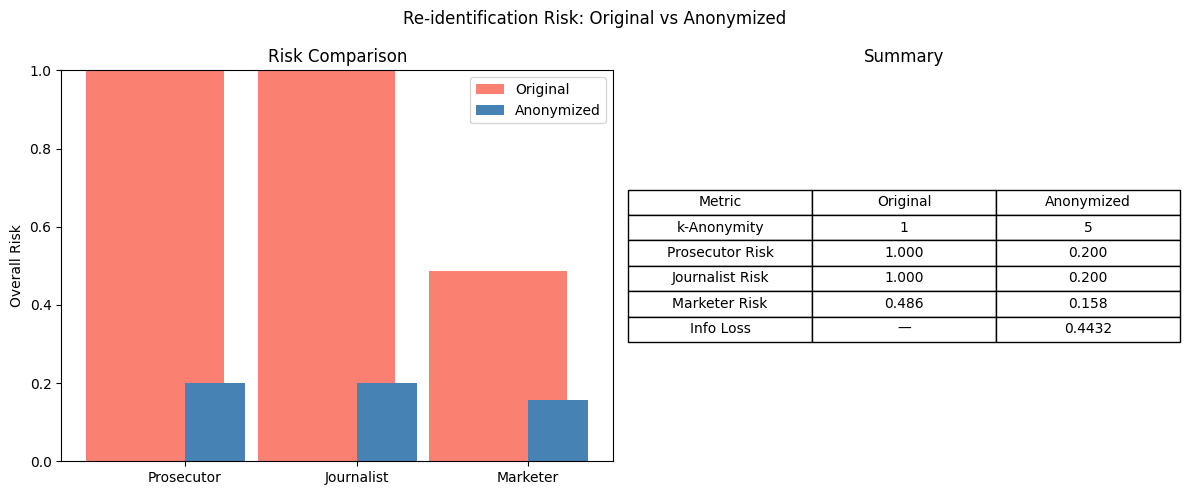

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Re-identification Risk: Original vs Anonymized")

risk_labels = ["Prosecutor", "Journalist", "Marketer"]
original_risks = [
    original_risk.prosecutor.overall_risk,
    original_risk.journalist.overall_risk,
    original_risk.marketer.overall_risk,
]
anon_risks = [
    anon_risk.prosecutor.overall_risk,
    anon_risk.journalist.overall_risk,
    anon_risk.marketer.overall_risk,
]

x = range(len(risk_labels))
axes[0].bar(x, original_risks, color="salmon", label="Original")
axes[0].bar([i + 0.35 for i in x], anon_risks, width=0.35, color="steelblue", label="Anonymized")
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels(risk_labels)
axes[0].set_ylabel("Overall Risk")
axes[0].set_title("Risk Comparison")
axes[0].legend()
axes[0].set_ylim(0, 1)

summary = pd.DataFrame({
    "Metric": ["k-Anonymity", "Prosecutor Risk", "Journalist Risk", "Marketer Risk", "Info Loss"],
    "Original": [original_risk.k_anonymity, f"{original_risks[0]:.3f}", f"{original_risks[1]:.3f}", f"{original_risks[2]:.3f}", "—"],
    "Anonymized": [anon_risk.k_anonymity, f"{anon_risks[0]:.3f}", f"{anon_risks[1]:.3f}", f"{anon_risks[2]:.3f}", f"{metrics.information_loss:.4f}"],
})
axes[1].axis("off")
table = axes[1].table(cellText=summary.values, colLabels=summary.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
axes[1].set_title("Summary")

plt.tight_layout()
plt.show()

In [25]:
# Re-apply the same anonymization solution to a new batch of data without recomputing.
# new_batch = client.apply_anon(job_id=result.job_id, data="more_patient_data.csv")
# new_batch_df = pd.DataFrame(new_batch.data)